In [1]:
import pandas as pd

#lets load the data
df = pd.read_csv("/content/Preprocess_Weather_data.csv")
df.sample(10)

,Timestamp,PM2.5,PM10,Carbon_Monoxide_CO,Nitrogen_Dioxide_NO2,Sulphur_Dioxide_SO2,Ozone_O3,European_AQI,Temperature,Humidity,Wind_Speed,Air_Pressure,Rainfall,PM2.5_3h_Mean,PM2.5_3h_Std,PM2.5_6h_Mean,PM2.5_6h_Std,PM2.5_24h_Mean,PM2.5_24h_Std
18485,2025-02-10 04:00:00,30.6,35.0,1871.0,35.9,8.9,66.0,70,16.1,33,2.6,1015.0,0.0,27.633333,3.619853,25.283333,3.778580,36.454167,20.987905
21066,2025-05-28 17:00:00,36.8,47.7,820.0,89.2,10.2,22.0,65,27.7,43,6.8,996.9,0.0,32.166667,4.980295,24.750000,8.918464,30.650000,8.242783
24542,2025-10-20 13:00:00,56.5,58.2,2025.0,112.4,21.5,36.0,67,23.8,55,7.0,1012.3,0.0,40.133333,16.501616,31.766667,13.897866,34.125000,13.241018
21380,2025-06-10 19:00:00,45.1,62.9,864.0,78.4,8.3,20.0,63,32.0,24,6.8,998.8,0.0,51.333333,5.416949,47.250000,7.861488,29.412500,11.494358
14361,2024-08-22 08:00:00,16.9,33.2,334.0,4.6,12.5,192.0,71,31.7,55,10.2,1003.0,0.0,17.266667,0.351188,17.783333,0.870441,25.633333,7.554881
22429,2025-07-24 12:00:00,28.3,52.9,724.0,9.5,7.0,131.0,69,31.1,65,6.3,993.3,0.0,25.400000,2.594224,23.916667,2.347268,36.845833,14.225940
10868,2024-03-29 19:00:00,13.6,23.6,309.0,13.5,3.1,69.0,58,17.5,63,18.8,1012.6,0.0,15.200000,1.652271,19.550000,5.181795,20.712500,4.421815
18837,2025-02-24 20:00:00,41.1,44.4,677.0,82.9,8.4,11.0,58,14.5,59,4.0,1018.9,0.0,43.533333,2.354428,42.583333,3.074031,24.591667,13.311516
483,2023-01-22 02:00:00,45.3,66.6,1762.0,43.0,9.1,19.0,73,4.0,86,6.1,1018.6,0.0,40.766667,4.006661,46.266667,6.834228,41.770833,16.520303
4778,2023-07-20 01:00:00,35.0,50.3,741.0,38.7,5.7,31.0,63,24.8,92,0.0,1003.3,0.2,32.666667,3.137409,32.833333,2.633376,29.937500,9.067324


In [4]:
!pip install lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [5]:
df["AQI_6h_Forecast"] = df["European_AQI"].shift(-6)

In [6]:
df.isnull().sum()

,0
Timestamp,0
PM2.5,0
PM10,0
Carbon_Monoxide_CO,0
Nitrogen_Dioxide_NO2,0
Sulphur_Dioxide_SO2,0
Ozone_O3,0
European_AQI,0
Temperature,0
Humidity,0


In [7]:
df.dropna(inplace=True)

In [8]:
X = df.drop(columns=[
    'Timestamp', 'AQI_3h_Forecast', 'Month', 'Day_Type', 'Hour', 'European_AQI', 'AQI_6h_Forecast'
], errors='ignore')

y = df['AQI_6h_Forecast']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
import joblib

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=0)
}

forecasting_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name} for 6-Hour Forecasting...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    forecasting_results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (%)": round(r2 * 100, 2)
    })

results_df = pd.DataFrame(forecasting_results).sort_values(by="R2 Score (%)", ascending=False)
print("\nFinal 6-Hour Forecasting Model Comparison Matrix.")
print("="*60)
print(results_df.to_string(index=False))

Training XGBoost for 6-Hour Forecasting...
Training LightGBM for 6-Hour Forecasting...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3983
[LightGBM] [Info] Number of data points in the train set: 24322, number of used features: 17
[LightGBM] [Info] Start training from score 69.281104
Training Random Forest for 6-Hour Forecasting...
Training CatBoost for 6-Hour Forecasting...

Final 6-Hour Forecasting Model Comparison Matrix.
        Model  MAE  RMSE  R2 Score (%)
Random Forest 2.44  4.09         92.22
     LightGBM 2.85  4.50         90.58
      XGBoost 2.82  4.52         90.48
     CatBoost 3.19  5.06         88.06


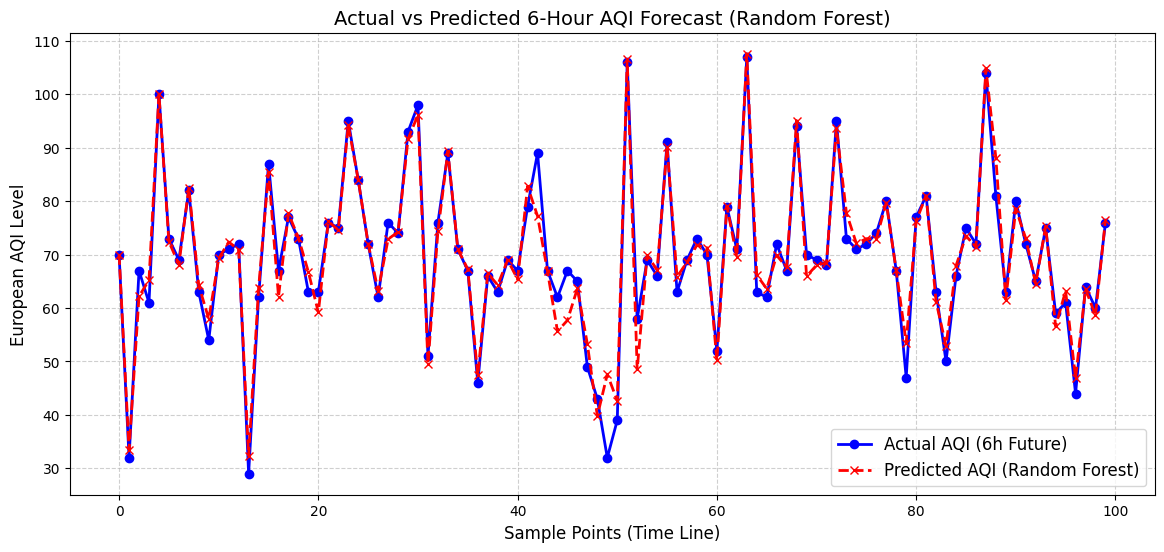

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:100], label='Actual AQI (6h Future)', color='blue', linewidth=2, marker='o')
plt.plot(y_pred_final[:100], label=f'Predicted AQI ({best_model_name})', color='red', linestyle='--', linewidth=2, marker='x')

plt.title(f"Actual vs Predicted 6-Hour AQI Forecast ({best_model_name})", fontsize=14)
plt.xlabel("Sample Points (Time Line)", fontsize=12)
plt.ylabel("European AQI Level", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [12]:
import joblib
import os

os.makedirs("models", exist_ok=True)

rf_forecaster = trained_models["Random Forest"]
model_save_path = "models/random_forest_6hrsaqi_forecaster.pkl"

joblib.dump(rf_forecaster, model_save_path)

print(f"Model has been saved successfully {model_save_path}")

Model has been saved successfully models/random_forest_6hrsaqi_forecaster.pkl
